# Climate Change Data Analysis

Course: DAT4004-S2-23 ??

Author: Tom Rowan, st20285213

Tutor: Priya

## Introduction

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

*The objective of the proposed data analysis tasks is to provide up-to-date and meaningful analysis that will help users to inform decisions on future policy and services.*

---

## Import Libraries

If you have any issues with importing the various libraries, a requirements file is included.

```
jupyter
pandas
matplotlib
scikit-learn
ipykernel
seaborn
plotly
chart_studio
nbformat
tabulate
```

In [212]:
# Install Requirements Using Pip
#%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [213]:
# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.pyplot import figure
%matplotlib inline

# SciKit Learn
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

# Seaborn Graphs
import seaborn as sns

# Plotly
import chart_studio
import plotly.figure_factory as ff
import chart_studio.plotly as py
import plotly.graph_objects as go
import plotly.express as px

# Other Standard Libraries
import os
import re
import json
from urllib import request
from tabulate import tabulate
import math
import statistics


### Check for Internet Connectivity

A free account is required to utilise PlotLy graphs, and will require live Internet access to run this notebook properly.

If you are not online, the notebook will display pre-generated png files of the intended output for these graphs.

In [214]:
online = False

def check_internet():
    try:
        request.urlopen('http://connectivitycheck.gstatic.com/generate_204', timeout=3)
        return True
    except request.URLError as err:
        return False
    
if check_internet() == True:
    print ("We are online. :)")
    online = True

    url_prefix = "https://datascience.daemonchild.com/year1/dat4004/"
    
    # Initialise Plotly with credentials
    plotly_username = 'st20285213' 
    plotly_key = 'WiFyUClTkfEwCduNDlpU'     # <-- Note to self, regenerate new key after August 2024
    chart_studio.tools.set_credentials_file(username=plotly_username, api_key=plotly_key)

    #countries_csv_url = "https://raw.githubusercontent.com/daemonchild/dat4004-data-science-fundamentals/main/datasets/countries/world-regions-according-to-the-world-bank.csv?token=GHSAT0AAAAAACQ44HN4VOT45G7DEZRN6NOEZSGEINA"
    #dev_indic_csv_url = "https://raw.githubusercontent.com/daemonchild/dat4004-data-science-fundamentals/main/datasets/wbank_dev_indicators/38b7cb7a-172f-4be9-a48d-34d89fca9fc9_Data.csv?token=GHSAT0AAAAAACQ44HN46SJCSXTOOET6PM6YZSGGJ6A"

else:
    print ("No internet connection, will use pre-generated graphs/tables.")
    url_prefix = "../datasets/"

We are online. :)


---

# Task 1 - Import and Preprocess Data Sets

>- i.	Download the dataset
>- ii.	Do the necessary preprocessing for example i.e., check for any null value or outlier. If found replace that with mean value and delete repeating factors as necessary.

Reference: https://databank.worldbank.org/reports.aspx?source=2&Topic=19#advancedDownloadOptions

Accessed: 10/05/2024

Reference: https://ourworldindata.org/world-region-map-definitions

Accessed:  15/05/2024



## UNSD Countries and Region Dataset

The United Nations provides a simple dataset which classifies each country by region. This data will be used to enrich analysis of the main datasets.

To explore the relative size of the regions, I have performed counting operations, and plotted the results. The data is relatively clean and requires only the removal of non-relevant columns. The country names in this data set are 'better' than those in the World Bank datasets, and this data includes regions ("Americas") and subregions ("Northern Europe") that can be mapped to countries in the World Bank dataset. This will give two levels of aggregation - global regions, and subregions.

Dataset source: https://unstats.un.org/unsd/methodology/m49/overview/

Note that it is not possible to provide a link directly to a csv file due to the download process on this page.

I have put the dataset online here: https://datascience.daemonchild.com/year1/dat4004/datasets/unsd/unsd-countrycodes.csv

In [215]:
# Load Data Set
_csv_url = f"{url_prefix}datasets/unsd/unsd-countrycodes.csv"
print (f"Loading data from {_csv_url}")
countries_df = pd.read_csv(_csv_url, delimiter=";")

# Rename Columns
countries_df.rename(columns={'Country or Area': 'Country', 'Region Name': 'Region', 'ISO-alpha3 Code': 'ISOcode','Sub-region Name': 'Subregion','Intermediate Region Name': 'Intregion'}, inplace=True)

# Fill in blanks with a zero.
countries_df = countries_df.fillna(0)

countries_df.columns


Loading data from https://datascience.daemonchild.com/year1/dat4004/datasets/unsd/unsd-countrycodes.csv


Index(['Global Code', 'Global Name', 'Region Code', 'Region',
       'Sub-region Code', 'Subregion', 'Intermediate Region Code', 'Intregion',
       'Country', 'M49 Code', 'ISO-alpha2 Code', 'ISOcode',
       'Least Developed Countries (LDC)',
       'Land Locked Developing Countries (LLDC)',
       'Small Island Developing States (SIDS)'],
      dtype='object')

In [216]:
# The subregion and intermediate regions are combined, using the more localised 'Intermediate region' in preference.
countries_df['Intregion'] = np.where(countries_df['Intregion'] == 0, countries_df['Subregion'], countries_df['Intregion'])

# Remove the Subregion column and all others not required, and rename  Intregion
countries_df = countries_df.loc[:, ['Country','Region','ISOcode','Intregion']]
countries_df.rename(columns={'Intregion': 'Subregion'}, inplace=True)

# Manually Label Antartica for completeness; there should be no data anyway (in theory).
countries_df.loc[countries_df['Country'] == "Antarctica", "Region"] = "Antarctica"
countries_df.loc[countries_df['Country'] == "Antarctica", "Subregion"] = "Antarctica"

In [217]:
# Produce Lists
countries = list(countries_df['Country'].astype(str).unique())
regions = list(countries_df['Region'].astype(str).unique())
subregions = list(countries_df['Subregion'].astype(str).unique())
country_codes = list(countries_df['ISOcode'].astype(str).unique())

# Sort these...
countries.sort()
regions.sort()
subregions.sort()
country_codes.sort()
print (f"Regions ({len(regions)}): {regions}")
print ()
print (f"Subregions ({len(subregions)}): {subregions}")
print ()
print (f"Countries ({len(countries)}): {countries}")
print ()
print (f"Countries ({len(country_codes)}): {country_codes}")

Regions (6): ['Africa', 'Americas', 'Antarctica', 'Asia', 'Europe', 'Oceania']

Subregions (23): ['Antarctica', 'Australia and New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'Melanesia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'South-eastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe']

Countries (248): ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia (Plurinational State of)', 'Bonaire, Sint Eustatius and Saba', 'Bosnia and Herzegovina', 'Botswana', 'Bouvet Island', 'Brazil', 'British Indian Ocean Territory', 'B

In [218]:
# Show link between region and subregion
print ("Regions and Subregion members (in rows):")
subregion_gb = countries_df.groupby(by=['Region'])
print (tabulate(subregion_gb.Subregion.unique()))
print()
print ("Subregions per Region")
region_count_table = countries_df[['Country','Region']].groupby(['Region'])['Country'].count()
print (region_count_table)
print ()
print ("Countries per Subregion")
subregion_count_table = countries_df[['Country','Subregion']].groupby(['Subregion'])['Country'].count()
print (subregion_count_table)

Regions and Subregion members (in rows):
----------  -------------------------  ---------------  ------------------  ----------------  --------------
Africa      Northern Africa            Eastern Africa   Middle Africa       Southern Africa   Western Africa
Americas    Caribbean                  Central America  South America       Northern America
Antarctica  Antarctica
Asia        Central Asia               Eastern Asia     South-eastern Asia  Southern Asia     Western Asia
Europe      Eastern Europe             Northern Europe  Southern Europe     Western Europe
Oceania     Australia and New Zealand  Melanesia        Micronesia          Polynesia
----------  -------------------------  ---------------  ------------------  ----------------  --------------

Subregions per Region
Region
Africa        60
Americas      57
Antarctica     1
Asia          50
Europe        51
Oceania       29
Name: Country, dtype: int64

Countries per Subregion
Subregion
Antarctica                    1
Austr

Graphing this data:

Text(0, 0.5, 'Number of Countries')

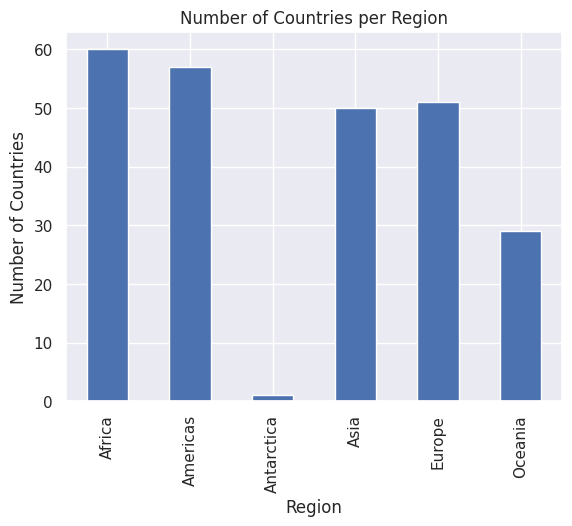

In [219]:
region_count_graph = region_count_table.plot(kind='bar', title='Number of Countries per Region');
region_count_graph.set_xlabel('Region')
region_count_graph.set_ylabel('Number of Countries')

Text(0, 0.5, 'Number of Countries')

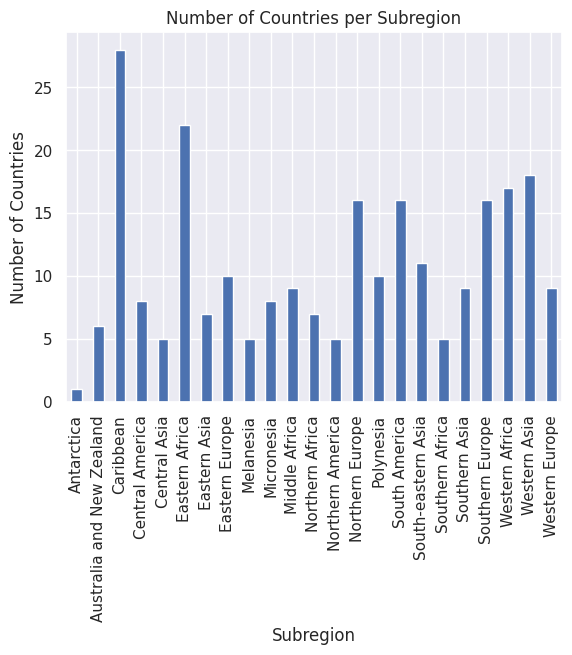

In [220]:
subregion_count_graph = subregion_count_table.plot(kind='bar', title='Number of Countries per Subregion');
subregion_count_graph.set_xlabel('Subregion')
subregion_count_graph.set_ylabel('Number of Countries')

### Mapping these Regions



In [221]:
fig = px.choropleth(countries_df, locations='ISOcode', color='Region', hover_name='Region',
                    projection='equirectangular', title='Region Groupings')
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":50}, dragmode=False)
fig.show()

In [222]:
fig = px.choropleth(countries_df, locations='ISOcode', color='Subregion', hover_name='Subregion',
                    projection='equirectangular', title='Sub-region Groupings')
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":50}, dragmode=False)
fig.show()

Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| countries_df | Country,Code,Region | Pandas DF |
| countries | Country Names | List |
| regions | Region Names | List |
| subregions | Subregion Names | List |
| country_codes | Country Codes | List |

## World Bank Development Indicator Data

I am attempting to explore how land usage affects climate change. The World Bank Development Indicators dataset includes use of land, electricity generation methods and volumes of CO2 produced by source.

In [223]:
# Load Data Set - Bottom 5 rows are blank or not data.
_csv_url = f"{url_prefix}datasets/wb/P_Data_Extract_From_World_Development_Indicators.csv"
print (f"Loading data from {_csv_url}")
devindic_df = pd.read_csv(_csv_url,skipfooter=5, engine='python')

# Drop columns with No data
devindic_df.drop("2022 [YR2022]",axis=1,inplace=True)
devindic_df.drop("2023 [YR2023]",axis=1,inplace=True)
devindic_df.columns

Loading data from https://datascience.daemonchild.com/year1/dat4004/datasets/wb/P_Data_Extract_From_World_Development_Indicators.csv


Index(['Series Name', 'Series Code', 'Country Name', 'Country Code',
       '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]',
       '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]',
       '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]',
       '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]',
       '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]',
       '2020 [YR2020]', '2021 [YR2021]'],
      dtype='object')

In [224]:
# Rename Columns to more useful names
numerical_fields = [str(x).zfill(2) for x in range(2000,2022)]
string_fields = ["SeriesName", "SeriesCode", "Country_WB", "ISOcode"]   # <-- Country_WB for WorldBank name, allows merge later
devindic_df.columns = (string_fields + numerical_fields)

devindic_df.columns


Index(['SeriesName', 'SeriesCode', 'Country_WB', 'ISOcode', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021'],
      dtype='object')

In [225]:
# Define lists
series_codes = (list(devindic_df['SeriesCode'].astype(str).unique()))
series_names = (list(devindic_df['SeriesName'].astype(str).unique()))


### Series Code Analysis

Here I am investating the series code. It is made up of a number of tokens which identify the dataset purpose. Understanding this code will allow easier searching of the data series for relevant data.

In [226]:

# Extract Dataset containing Series Information
series_data_df= pd.DataFrame()
series_data_df['SeriesCode'] = devindic_df['SeriesCode'].unique()
series_data_df['SeriesName'] = devindic_df['SeriesName'].unique()

series_data_df = series_data_df.sort_values(by='SeriesCode')

print (tabulate(series_data_df, tablefmt="pipe", headers="keys"))


|    | SeriesCode           | SeriesName                                                                                      |
|---:|:---------------------|:------------------------------------------------------------------------------------------------|
|  0 | AG.LND.AGRI.K2       | Agricultural land (sq. km)                                                                      |
|  1 | AG.LND.AGRI.ZS       | Agricultural land (% of land area)                                                              |
| 41 | AG.LND.ARBL.HA       | Arable land (hectares)                                                                          |
|  2 | AG.LND.ARBL.ZS       | Arable land (% of land area)                                                                    |
| 66 | AG.LND.CREL.HA       | Land under cereal production (hectares)                                                         |
| 69 | AG.LND.CROP.ZS       | Permanent cropland (% of land area)                                       

**edit me!**

Create a Unit column by splitting the "SeriesName" column - the name of the series - into two parts.

For example "Agricultural land (sq. km)" becomes SeriesName: "Agricultural Land", Unit: "SQ. KM".

In [227]:
# https://stackoverflow.com/questions/13784192/creating-an-empty-pandas-dataframe-and-then-filling-it
# Building into a list first as per ^

_temp_list = []

for _index, _row in series_data_df.iterrows():

    _code_tokens = _row['SeriesCode'].split(".")
    _num_tokens = len(_code_tokens)
    
    if _num_tokens == 3:
        _row['UnitCode'] = "--"
    elif _num_tokens == 4:
        _row['TypeCode'] = '-'.join(map(str,_code_tokens[1:3]))
        _row['UnitCode'] = _code_tokens[-1]  
    else:
        _row['UnitCode'] = _code_tokens[-1]
        _row['TypeCode'] = '-'.join(map(str,_code_tokens[1:(_num_tokens-2)]))

    _row['StudyCode']= _code_tokens[0]

    _name_tokens = _row['SeriesName'].split("(")
    if len(_name_tokens)> 1:
        _row['GraphUnit'] = _name_tokens[1].rstrip(")").upper()
    else:
        _row['GraphUnit'] = "People"
    _temp_list.append(_row)

# Finally replace into series_data_df
series_data_df = pd.DataFrame(_temp_list)




In [228]:
print (tabulate(series_data_df, tablefmt="pipe", headers="keys"))

|    | SeriesCode           | SeriesName                                                                                      | TypeCode    | UnitCode   | StudyCode   | GraphUnit                              |
|---:|:---------------------|:------------------------------------------------------------------------------------------------|:------------|:-----------|:------------|:---------------------------------------|
|  0 | AG.LND.AGRI.K2       | Agricultural land (sq. km)                                                                      | LND-AGRI    | K2         | AG          | SQ. KM                                 |
|  1 | AG.LND.AGRI.ZS       | Agricultural land (% of land area)                                                              | LND-AGRI    | ZS         | AG          | % OF LAND AREA                         |
| 41 | AG.LND.ARBL.HA       | Arable land (hectares)                                                                          | LND-ARBL    | HA         | AG   

In [229]:
# Drop Series Name from one table
series_data_df.drop(['SeriesName'], axis=1, inplace=True)

# Back fill from the series analysis above

_columns_to_merge = series_data_df.columns.difference(devindic_df.columns)
devindic_df = pd.merge(devindic_df, series_data_df, on=["SeriesCode"], how='left')

devindic_df.columns


Index(['SeriesName', 'SeriesCode', 'Country_WB', 'ISOcode', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', 'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit'],
      dtype='object')


In [230]:
devindic_df.shape

(23142, 30)


In [231]:
devindic_df.tail(2)

,SeriesName,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,TypeCode,UnitCode,StudyCode,GraphUnit
23140,Total fisheries production (metric tons),ER.FSH.PROD.MT,Upper middle income,UMC,71078889.4,69156430.7,71856148.68,71218867.45,77202528.29,78992995.91,...,99408754.95,101594266.52,106297663.06,105787856.91,108038766.6,111435146.39,FSH-PROD,MT,ER,METRIC TONS
23141,Total fisheries production (metric tons),ER.FSH.PROD.MT,World,WLD,137012144.68,136763113.54,140159792.35,140238806.47,149082261.24,151975436.07,...,197685290.2,205148563.7,211435206.37,211656620.38,212154014.94,216872257.81,FSH-PROD,MT,ER,METRIC TONS


The dataset contains a large number of elements where there is a null value; where there is no recorded data. This has been recorded in the dataset as a '..' value, and the datatype of the columns were consequently marked as 'object', rather than a float value during the CSV import. This indicates an unreported value for a given year.

In review of the data, there are also some zero values in the data (see next cell). These appear to be used interchanegably with the "..". For the purposes of this study, unreported figures and zero figures are equivalent, as a zero figure is, in most cases, highly unlikely excepting small island nations.

In [232]:
# Showing a line in the dataset with multiple '..' values:
devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]

,SeriesName,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,TypeCode,UnitCode,StudyCode,GraphUnit
983,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,Sudan,SDN,16.91787254253,..,..,..,..,..,...,..,..,..,..,..,..,LND-EL5M,K2,AG,SQ. KM


In [233]:
# Replacing the ".." marker in all numerical data columns.
for column in numerical_fields:
    devindic_df[column] = devindic_df[column].replace("..","0")

In [234]:
# Showing the same line in the dataset:
devindic_df.loc[devindic_df['Country_WB'] == "Sudan"].loc[devindic_df['SeriesCode'] == "AG.LND.EL5M.UR.K2"]

,SeriesName,SeriesCode,Country_WB,ISOcode,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,TypeCode,UnitCode,StudyCode,GraphUnit
983,Urban land area where elevation is below 5 met...,AG.LND.EL5M.UR.K2,Sudan,SDN,16.91787254253,0,0,0,0,0,...,0,0,0,0,0,0,LND-EL5M,K2,AG,SQ. KM


## Joining UNSD and WorldBank Tables

I am merging the tables based on the ISOcode for the country.

In [235]:
country_data_df = pd.merge( devindic_df, countries_df, on=["ISOcode"], how='left')

# Remove the World Bank Country Name
country_data_df.drop(columns=['Country_WB'], inplace=True)

Set Column Types now that we have built the entire dataframe.

In [236]:

# Generate a list of the non-numerical column names
print ("Non-numerical fields:")
print (f"{string_fields} --> ", end="")
string_fields = [sf for sf in country_data_df.columns if sf not in numerical_fields]
print (string_fields)

for column in string_fields:
   country_data_df[column] = country_data_df[column].astype(str)

for column in numerical_fields:
   country_data_df[column] = country_data_df[column].astype(float)

country_data_df.dtypes

# Write out to CSV
country_data_df.to_csv("../outputs/wb_merged_unsd_on_isocode.csv", sep=',', encoding='utf-8')

Non-numerical fields:
['SeriesName', 'SeriesCode', 'Country_WB', 'ISOcode'] --> ['SeriesName', 'SeriesCode', 'ISOcode', 'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit', 'Country', 'Region', 'Subregion']


### Separate Aggregated Data, and remove outliers
As well as data for distinct countries, the World Bank dataset also includes data from aggregated regions, but these are not compatible with the sub regions. This data can be extracted from the working data set and saved for later use. The Kosovo country code is not found in the UNSD data. It is an empty row and can also be removed, as shown from this extract from the CSV:

> Agricultural Land,AG.LND.AGRI.K2,Kosovo,XKX,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..

To do this, I am using the country_codes extracted from the UNSD dataset, and using the intersection between the "ISOcode" column to filter the data into two dataframes. I have saved these to CSV once completed.

In [237]:
# Extract Regional Data (NB if NOT in)
regional_data_only_df = pd.DataFrame(country_data_df[~country_data_df['ISOcode'].isin(country_codes)])
#regional_data_only_df[["ISOcode","Country"]].drop_duplicates(inplace=True)
regional_data_only_df.to_csv("../outputs/wb_regional_data_discarded.csv")

# Country Data
country_data_df = pd.DataFrame(country_data_df[country_data_df['ISOcode'].isin(country_codes)])
country_data_df.to_csv("../outputs/country_data.csv")


This dataset comprises multiple subtables of unrelated data concatenated, sharing the same column names. The Series Code is the key to each sub-table, each containing a complete set of records for each country. To confirm:

In [238]:
# Number of records per dataset, also equals the number of countries
country_data_df.groupby(['SeriesCode'])['Country'].count().head(3)

SeriesCode
AG.LND.AGRI.K2    215
AG.LND.AGRI.ZS    215
AG.LND.ARBL.HA    215
Name: Country, dtype: int64

In [239]:
country_data_df.columns

Index(['SeriesName', 'SeriesCode', 'ISOcode', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit', 'Country', 'Region',
       'Subregion'],
      dtype='object')

In [240]:
print(country_data_df.shape)

(18705, 32)


In [241]:
#To extract an individual sub table, the following example can be used:
    
df_AG_LND_AGRI_K2 = country_data_df.loc[country_data_df['SeriesCode'] == "AG.LND.AGRI.K2"]
df_AG_LND_AGRI_K2.columns

Index(['SeriesName', 'SeriesCode', 'ISOcode', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       'TypeCode', 'UnitCode', 'StudyCode', 'GraphUnit', 'Country', 'Region',
       'Subregion'],
      dtype='object')

Define a graph function to plot each series.

In [242]:
def plot_data_series_years (dataframe, ylabel="y axis", title="a graph", start=2000, end=2021, log=0):

    _range = [str(x).zfill(2) for x in range(start,end+1)]
    _years = pd.Index(_range)

    for _index, _row in dataframe.iterrows():
        _country = _row['Country']
        _country_data = _row[_years]

        # There *will* be divide by zero errors, trying to trap, but ensure that we fill with a true zero.
        if log == 10:
            _country_data = np.log10(_country_data.astype(float), out=np.zeros_like(_country_data), where=(_country_data>0.0))
        elif log == 2:
            _country_data = np.log2(_country_data.astype(float), out=np.zeros_like(_country_data), where=(_country_data>0.0))
        
        plt.plot(_years,_country_data,label=_country)
    #plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    fig = plt.gcf()
    fig.set_size_inches(15, 6, forward=True)

    plt.show()

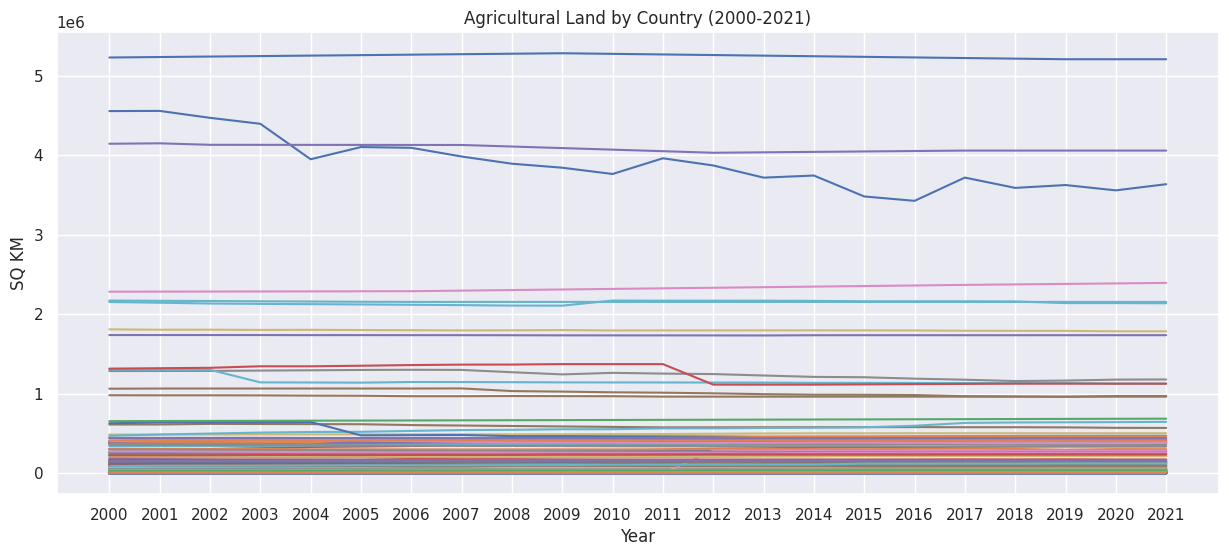

/home/tom/development/dat4004-data-science-fundamentals/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

/home/tom/development/dat4004-data-science-fundamentals/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

/home/tom/development/dat4004-data-science-fundamentals/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

/home/tom/development/dat4004-data-science-fundamentals/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

/home/tom/development/dat4004-data-science-fundamentals/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10

/home/tom/development/dat4004-data-science-fundamentals/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: Runt

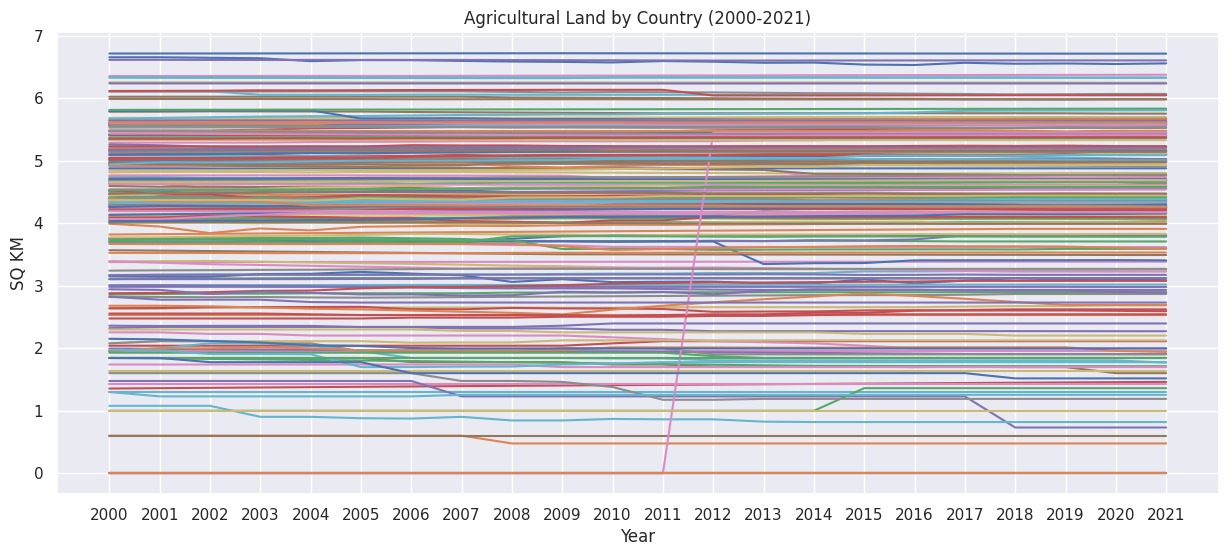

In [243]:
# Using df_AG_LND_AGRI_K2, Agricultural Land by Country (2000-2021)
plot_data_series_years (dataframe=df_AG_LND_AGRI_K2, ylabel="SQ KM", title="Agricultural Land by Country (2000-2021)", start=2000, end=2021)
plot_data_series_years (dataframe=df_AG_LND_AGRI_K2, ylabel="SQ KM", title="Agricultural Land by Country (2000-2021)", start=2000, end=2021, log=10)

Using the function, I will now plot all the data series in turn to ascertain the shape of the dataset graphically.

In [244]:
# NB run time approx: 55 sec

def get_unit (dataframe):
    return str(dataframe["GraphUnit"].unique()[0])

def get_seriesname (dataframe):
    return str(dataframe["SeriesName"].unique()[0])

for _series in series_codes:
    _series_data = country_data_df.loc[country_data_df['SeriesCode'] == _series]
    _unit = get_unit(_series_data)
    _series_name = get_seriesname (_series_data)
    _title = str(_series_name + "(" +_unit+ ")")
    #plot_data_series_years (dataframe=_series_data, title=_title, ylabel=_unit)

This is clearly an unsuitable plot for clearly showing this data, (even using logarithmic values). However, these plots how the general 'shape' of the data sets for future reference. It will be useful to add a units column to each series.

Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| country_data_df| Country,Code,SeriesCode,{Data Values} | Pandas DF |
| regional_data_only_df | Country,Code,SeriesCode,{Data Values} | Pandas DF |
| series_code | Series Code | List |
| series_names | Series Names | List |


---

# Task 2 - Data Analysis



## Task Questions

The datasets available from the World Bank are extensive. I have collected together a wide selection of series from the Development Indicators range. This allows me to pose a number of questions that should provide insight for policy makers.

- Are CO2 emissions increasing over time?
- Rank regions by CO2 emissions. Who is worst?
- Predict Future CO2 Emission Trends
- Is there a link between population and birth-rate to CO2 emmissions?

- Does Land Usage Type Corollate to Total CO2 Emissions?
- Describe the trends in land use by region.

- Show elecricial consumption over time vs renewable production, by region.
- Is there a correlation between electricity priduced by renewables and CO2 emissions?


what insights.... is there corrolation.... renable vs Co2.

What should policy makers do with this information...?

task 3 clustering basedon regression.

## Q1: Are CO2 emissions increasing over time?

This is an interesting question because while it is common understanding that global emissions are increasing in general, this may not be true for all regions, or countries.

In this question, I will utilise data on total CO2 emissions.

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
EN.ATM.CO2E.KT | CO2 Emissions | Tons x 10^3 (KT)

In [855]:
# Extract C02 data for all countries
co2data_df = country_data_df.loc[country_data_df['SeriesCode'] == 'EN.ATM.CO2E.KT'].dropna()

# Remove 2021 - it's empty for all countries
co2data_df.drop('2021', axis=1, inplace=True)
co2_data_num_fields = numerical_fields.copy()
co2_data_num_fields.remove("2021")


As an initial review, I have mapped the data at the extremes of the data range - 2000 and 2020 - to review changes over the time series. From these maps, it's clear to see two facts:

- Global Emissions have increased. The scale of the legend on the maps demonstrates this clearly.
- The leader board of emitters has changed over time. 

In [246]:

fig = px.choropleth(co2data_df, locations='ISOcode', color='2000', hover_name='Country',
                    projection='equirectangular', title='CO2 Emissions by Country 2000', hover_data='2000')
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":50}, dragmode=False)
fig.show()

In [247]:
fig = px.choropleth(co2data_df, locations='ISOcode', color='2020', hover_name='Country',
                    projection='equirectangular', title='CO2 Emissions by Country 2020', hover_data='2020')
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":50}, dragmode=False)
fig.show()


To work towards the question result, I will first I will create totals for $CO_{2}$, grouped by Subregion and plot this data in it's raw form.

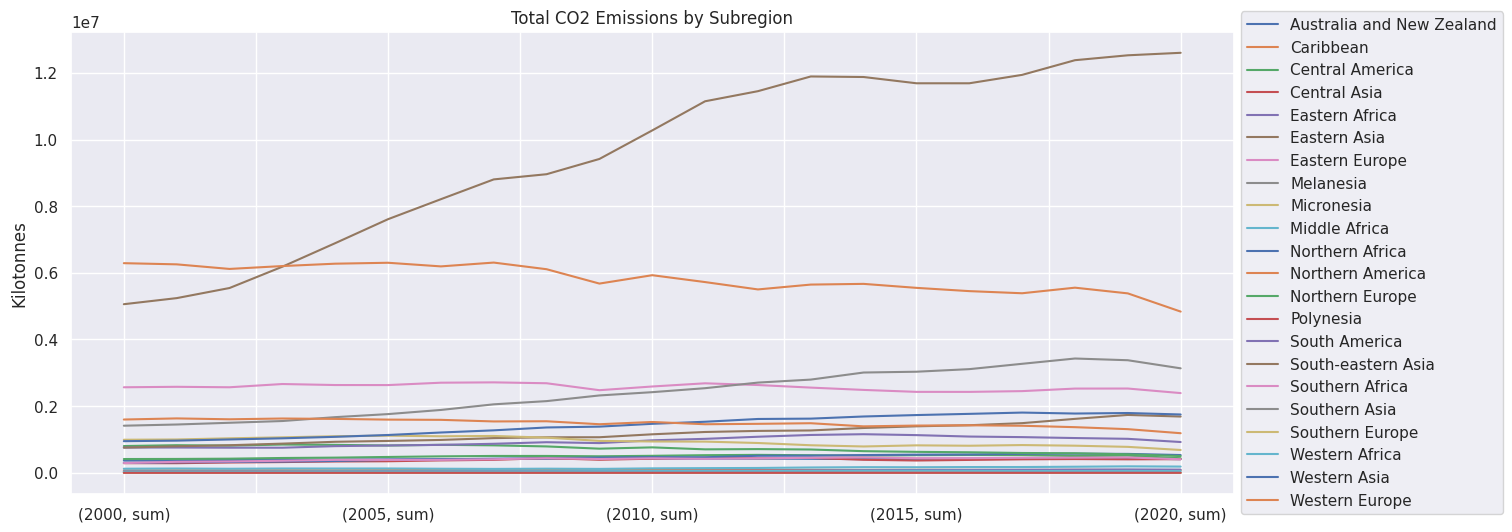

In [248]:
#Extract Data
co2data_subregion_gb = co2data_df.groupby(by='Subregion')[co2_data_num_fields].agg(['sum'])

# Create plot
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes", title="Total CO2 Emissions by Subregion");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

To show a total global output, I have applied a second summation:

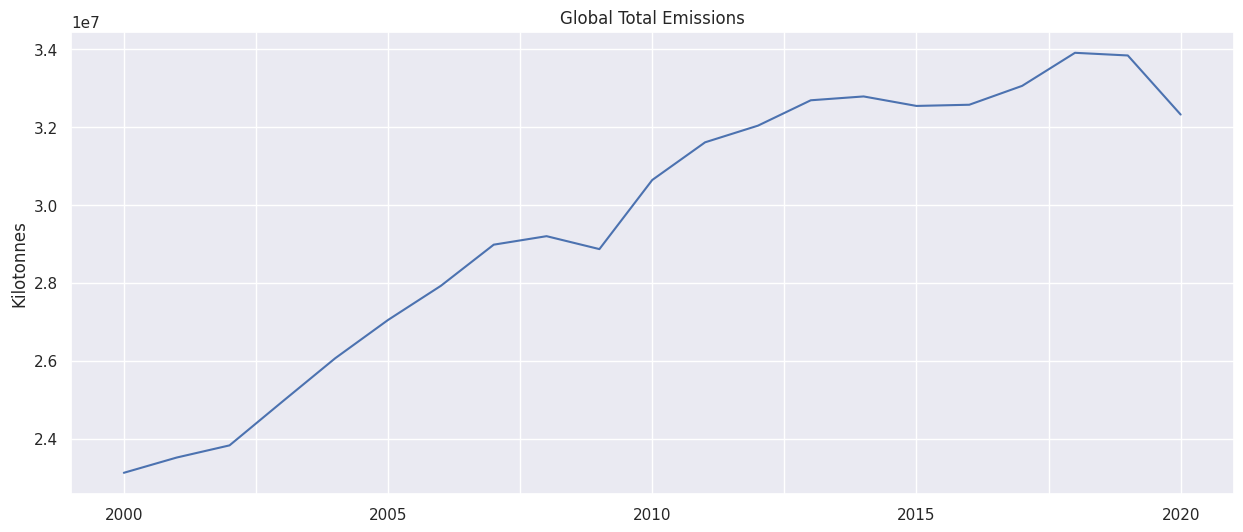

In [249]:
# Total CO2 emissions over time:
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb_all = co2data_df.groupby(by='Subregion')[co2_data_num_fields].sum().apply(['sum'])
co2data_subregion_gb_all.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes",title="Global Total Emissions",legend=False);
plt.show();


Is it all bad news however? Who reduced their emissions by the end of the 20 year period?

In [885]:
co2data_df['20YearDiff'] = co2data_df['2020'] - co2data_df['2000']

#co2_country_better_df = co2data_df[['Country','2000','2020']][(co2data_df['2000'] > co2data_df['2020'])]
co2_country_better_df = co2data_df[['Country','20YearDiff']][co2data_df['20YearDiff'] < 0.0]

In [893]:
print(co2_country_better_df)

                                                Country    20YearDiff
5856                                            Andorra -7.506760e+01
5863                                            Austria -4.396200e+03
5868                                           Barbados -9.203000e+01
5870                                            Belgium -3.191050e+04
5881                                           Bulgaria -9.283000e+03
5889                           Central African Republic -6.600000e+00
5900                                            Croatia -2.407500e+03
5901                                               Cuba -4.025300e+03
5903                                             Cyprus -3.559000e+02
5904                                            Czechia -3.588150e+04
5905                                            Denmark -2.524550e+04
5914                                            Estonia -7.834980e+03
5919                                            Finland -1.876760e+04
5920                

### Conclusion

From this analysis, it is clear that emissions are increasing, globally, despite some regions and individual countries changes. There are small downward bumps based on reaction to global events, but generally the worst polluters are still getting worse.

Global emissions peaked in 2018. Understandably, the effect of the SARS-CoV-2 pandemic is shown as a marked decrease, but the trends was already slightly downwards. The limitations of the dataset here mean that the study is limited. 

## Q2: Rank Regions by CO2 Emissions. Who is worst?

Following on from the last analysis, I will produce a global ranking table for each subregion over time.

In this question, I will utilise data on total $CO_{2}$ emissions.

I will first group the data by subregion, then sum the total emissions for each subregion. Once ordered by this sum, the rank can be assigned, in decending order (where highest value = rank 1, next highest = 2).

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
EN.ATM.CO2E.KT | CO2 Emissions | Tons x 10^3 (KT)

Extract Mean value for $CO_{2}$ by Region, to gain insight into whether a subregion is the highest producer, on average. This takes into account that some regions may include high volume emitters *and* at the same time include very low level emitters. This shows that Northern America has been consistenly a higher producer - on average - for longer than Eastern Asia.

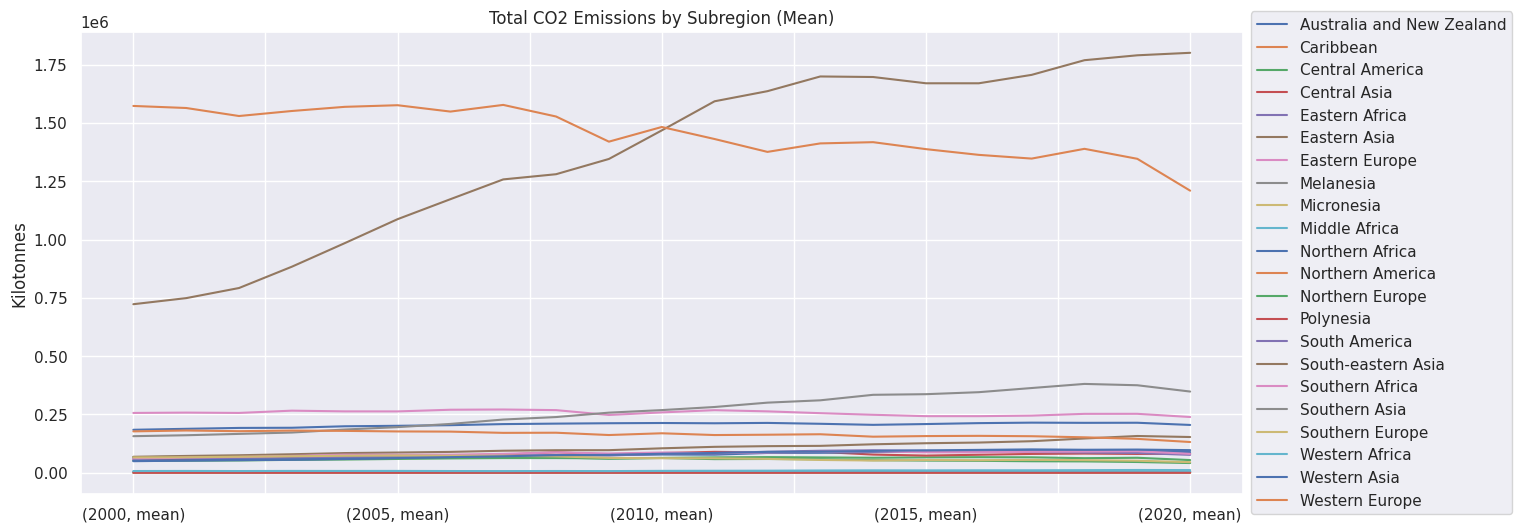

In [250]:
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb_mean = co2data_df.groupby(by='Subregion')[co2_data_num_fields].agg(['mean'])
co2data_subregion_gb_mean.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes", title="Total CO2 Emissions by Subregion (Mean)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()


To compare the values on a line graph requires a logarithmic scale. I will sum and then perform a $\log_{10}$ operation to allow for comparison between regions. Using this plot, we can see that there is a lot of movement over twenty years, thus the ranking table will be produced on a an annual basis.

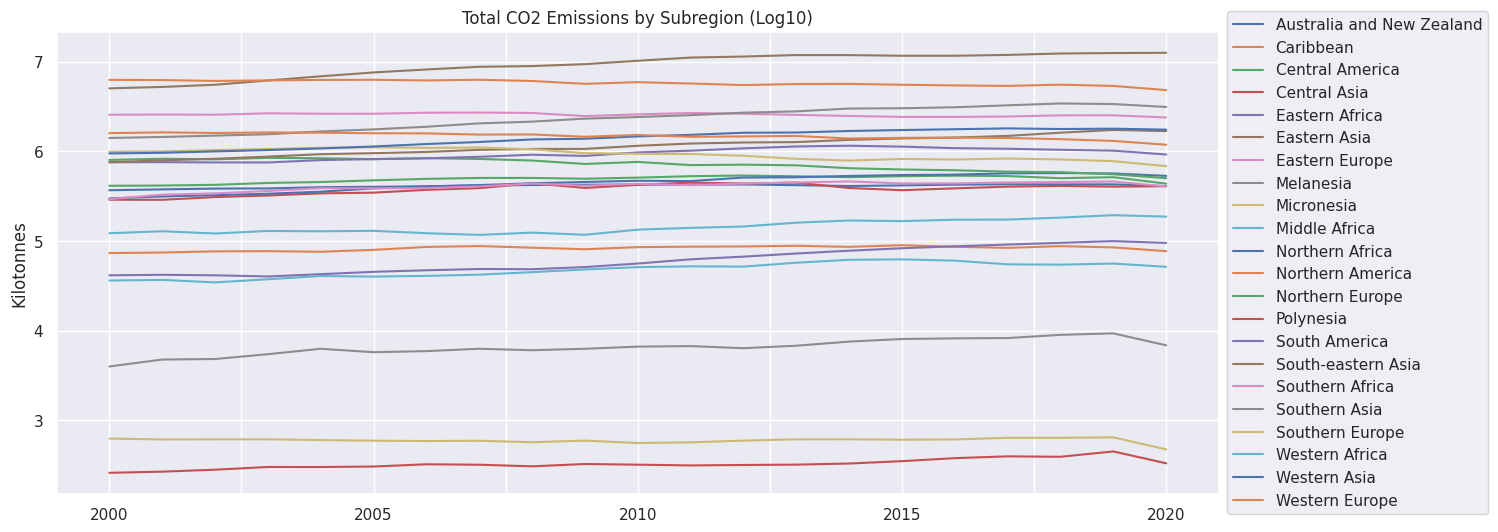

In [251]:
fig, ax = plt.subplots(figsize=(15,6))
co2data_subregion_gb_log = co2data_df.groupby(by='Subregion')[co2_data_num_fields].sum().apply(lambda x: np.log10(x))
co2data_subregion_gb_log.transpose().plot(kind='line', ax=ax, ylabel="Kilotonnes",title="Total CO2 Emissions by Subregion (Log10)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show();


The question asks who are the worst CO~2~ emitters. The graphs above clearly show that some regions are increasing their emissions, while others are reducing. A heatmap is another way of clearly showing the worst polluters, over time:

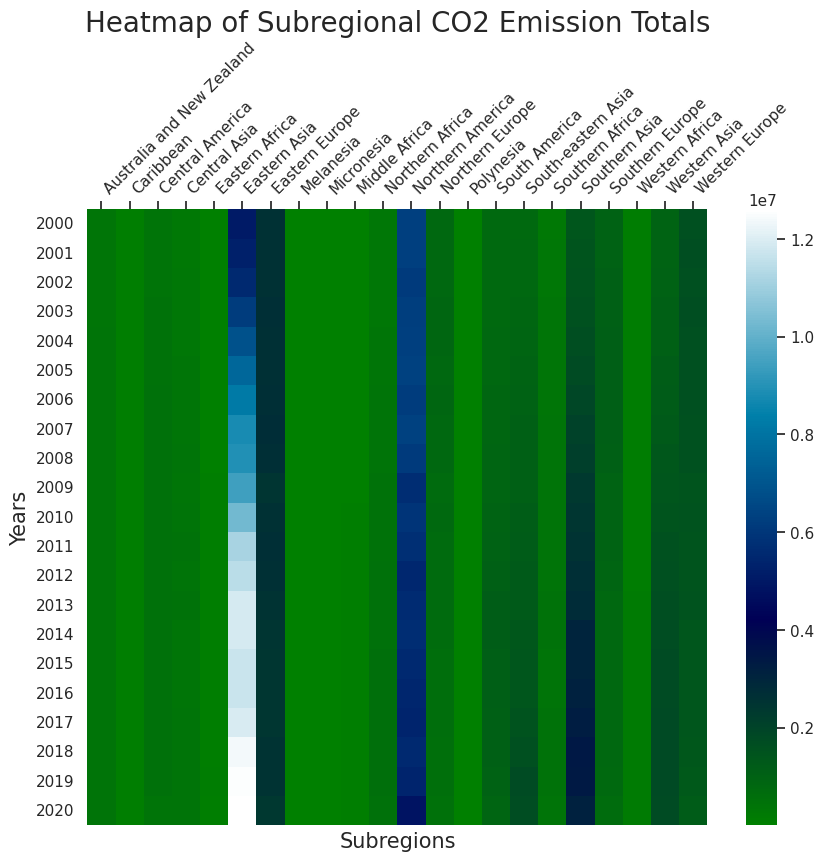

In [494]:
sns.set_theme()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(co2data_subregion_gb.transpose(),cmap="ocean");
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')
ax.set_yticklabels(co2_data_num_fields, rotation=0)
plt.xlabel('Subregions', fontsize = 15)
plt.ylabel('Years', fontsize = 15)
plt.title('Heatmap of Subregional CO2 Emission Totals', fontsize = 20)
ax.xaxis.tick_top() 


### Produce Ranking Table

To create a clear ranking table and plot, I will use a groupby with a sum, and then ranking.

In [253]:
# Build empty DataFrame, using appropriate year fields list
co2_subregion_rank_df = pd.DataFrame(columns=co2_data_num_fields)

# Build a ranking for each year in turn, and add to th eoutput dataframe
for _year in co2_data_num_fields:
    _new_df = co2data_df.groupby(by='Subregion')[_year].agg(['sum']).sort_values(by='sum', ascending=False).rank(ascending=False)
    co2_subregion_rank_df[_year] = _new_df

print(co2_subregion_rank_df)



                           2000  2001  2002  2003  2004  2005  2006  2007  \
Subregion                                                                   
Northern America            1.0   1.0   1.0   1.0   2.0   2.0   2.0   2.0   
Eastern Asia                2.0   2.0   2.0   2.0   1.0   1.0   1.0   1.0   
Eastern Europe              3.0   3.0   3.0   3.0   3.0   3.0   3.0   3.0   
Western Europe              4.0   4.0   4.0   4.0   5.0   5.0   5.0   5.0   
Southern Asia               5.0   5.0   5.0   5.0   4.0   4.0   4.0   4.0   
Southern Europe             6.0   6.0   6.0   6.0   6.0   7.0   7.0   7.0   
Western Asia                7.0   7.0   7.0   7.0   7.0   6.0   6.0   6.0   
Northern Europe             8.0   8.0   9.0   9.0   9.0  10.0   9.0  10.0   
South America               9.0  10.0  10.0  10.0  10.0   9.0  10.0   9.0   
South-eastern Asia         10.0   9.0   8.0   8.0   8.0   8.0   8.0   8.0   
Central America            11.0  11.0  11.0  11.0  11.0  11.0  11.0  11.0   

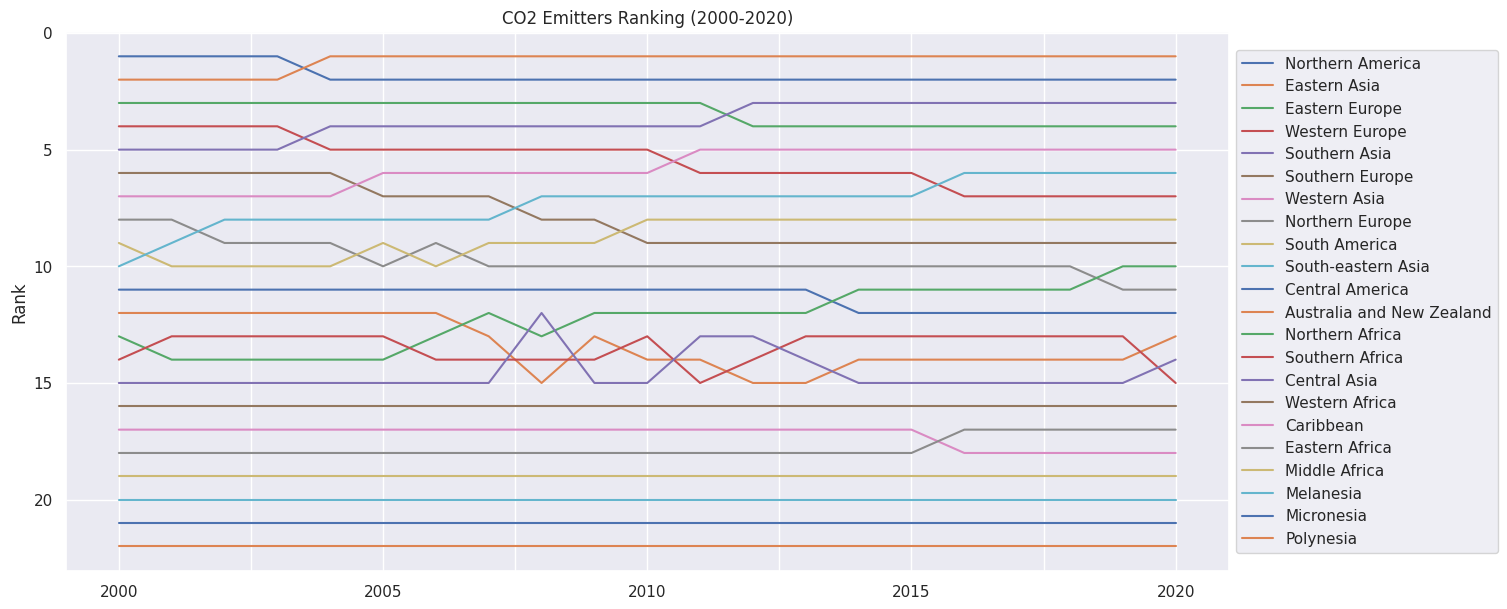

In [254]:
# Finally plot ranking over time.
fig, ax = plt.subplots(figsize=(15,7))
co2_subregion_rank_df.transpose().plot(kind='line', ax=ax, ylabel="Rank", title="CO2 Emitters Ranking (2000-2020)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.gca().invert_yaxis()
plt.show();

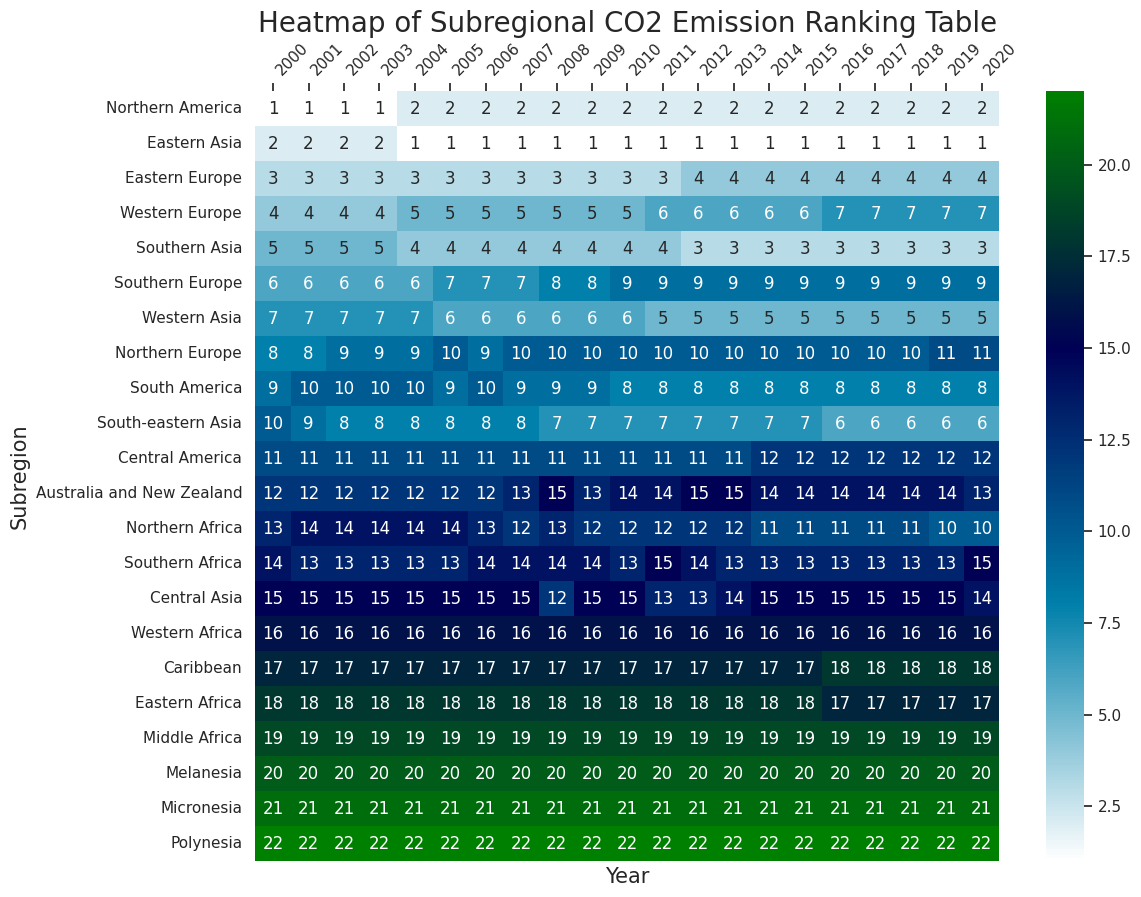

In [279]:
sns.set_theme()
plt.figure(figsize=(12, 10))
ax = sns.heatmap(co2_subregion_rank_df,cmap="ocean_r",annot=True);
ax.set_xticklabels(co2_data_num_fields, rotation=45, ha='left')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.xaxis.tick_top()
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Subregion', fontsize = 15)
plt.title('Heatmap of Subregional CO2 Emission Ranking Table', fontsize = 20)
plt.show()

It is also easy to produce a country rank table, although this will be limited to the Top 20 worst $CO_{2}$ polluters. This limit will create holes in the data where countries drop out of this ranking, and no data for those replacing them.

In [256]:
# Build empty DataFrame, using appropriate year fields list
co2_country_rank_df = pd.DataFrame(columns=co2_data_num_fields)

# Build a ranking for each year in turn, and add to th eoutput dataframe
for _year in co2_data_num_fields:
    _new_df = co2data_df.groupby(by='Country')[_year].agg(['sum']).sort_values(by='sum', ascending=False).rank(ascending=False).head(20)
    co2_country_rank_df[_year] = _new_df

print(co2_country_rank_df)

                                                    2000  2001  2002  2003  \
Country                                                                      
United States of America                             1.0   1.0   1.0   1.0   
China                                                2.0   2.0   2.0   2.0   
Russian Federation                                   3.0   3.0   3.0   3.0   
Japan                                                4.0   4.0   4.0   4.0   
India                                                5.0   5.0   5.0   5.0   
Germany                                              6.0   6.0   6.0   6.0   
United Kingdom of Great Britain and Northern Ir...   7.0   7.0   7.0   8.0   
Canada                                               8.0   8.0   8.0   7.0   
Republic of Korea                                    9.0   9.0   9.0   9.0   
Italy                                               10.0  10.0  10.0  10.0   
Mexico                                              11.0  11.0  

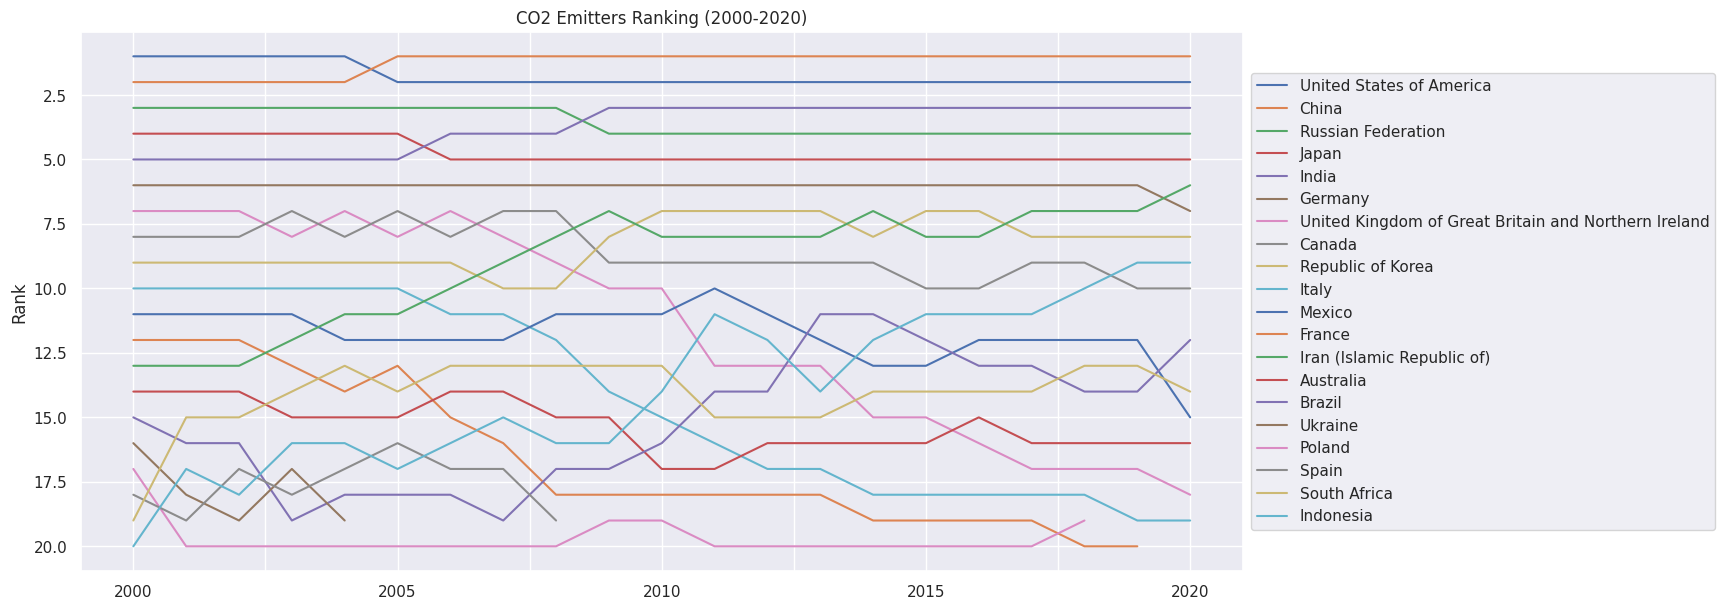

In [257]:
fig, ax = plt.subplots(figsize=(15,7))
co2_country_rank_df.transpose().plot(kind='line', ax=ax, ylabel="Rank", title="CO2 Emitters Ranking (2000-2020)");
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.gca().invert_yaxis()
plt.show();

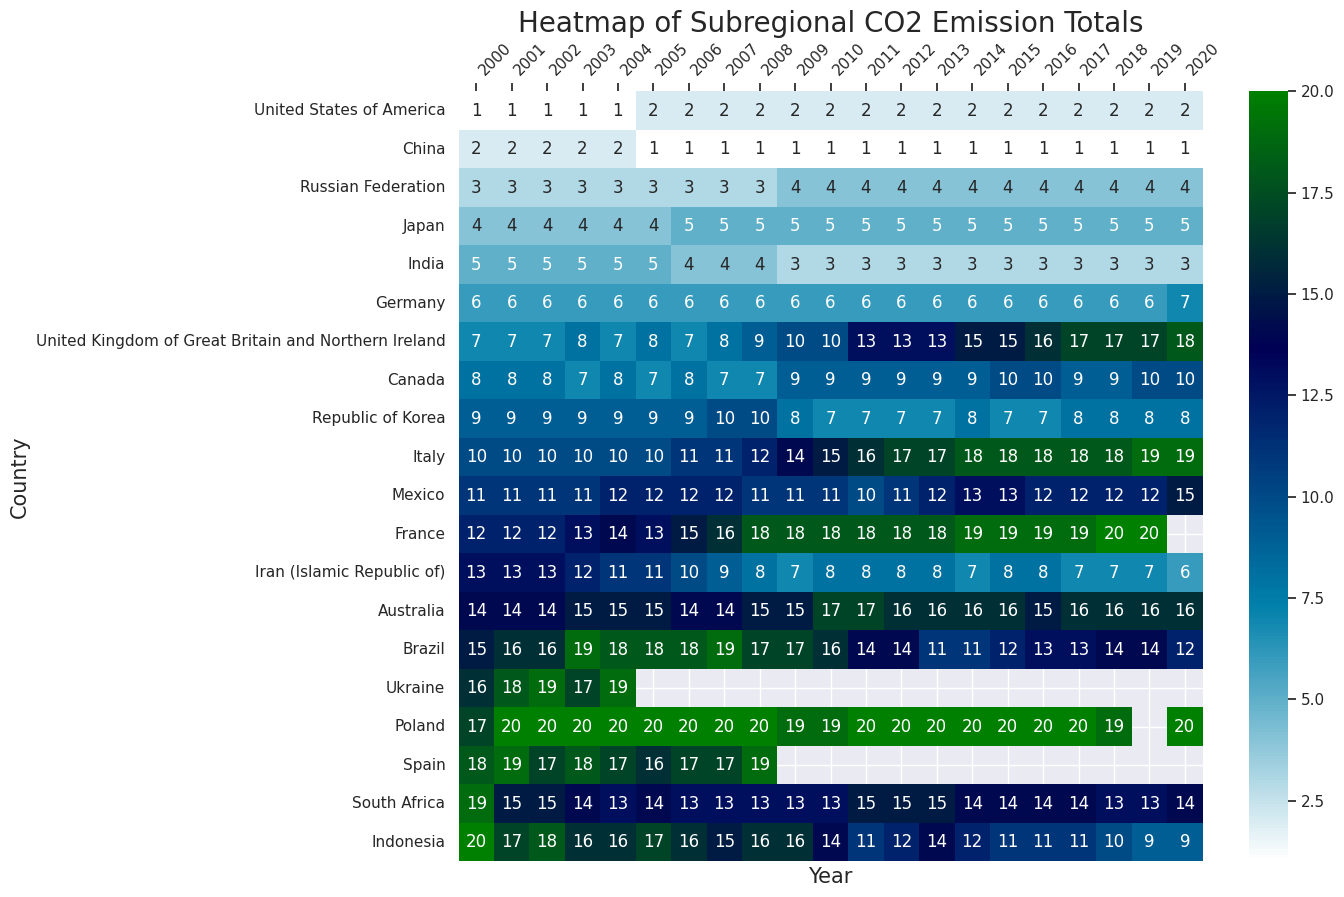

In [280]:
sns.set_theme()
plt.figure(figsize=(12, 10))
ax = sns.heatmap(co2_country_rank_df,cmap="ocean_r",annot=True);
ax.set_xticklabels(co2_data_num_fields, rotation=45, ha='left')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.xaxis.tick_top()
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Country', fontsize = 15)
plt.title('Heatmap of Subregional CO2 Emission Totals', fontsize = 20)
plt.show()

### Conclusion

There are clear consistent winners on the CO2 Emissions Leaderboard. While the general trend is upwards, as question one shows, the rankings change. Why countries are moving in the emissions ranking is not clear without further analysis. Does the UK move from 7th to 18th because it has drastically reduced emissions, or because others have increased theirs equally drastically?

Policy makers can use this chart to see how their country - or region - is trending against others.


---
## Q3: Predict Future CO2 Emission Trends

In the previous questions, I explored the historical figures for global CO2 emissions. In this question, I will aim to produce trending data for each subregion.

In this question, I will utilise data on total $CO_{2}$ emissions. I have already created some the datasets required to begin this question.

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
EN.ATM.CO2E.KT | CO2 Emissions | Tons x 10^3 (KT)


In [337]:
# Extract C02 data for all countries (Reload Fresh)
co2data_df = country_data_df.loc[country_data_df['SeriesCode'] == 'EN.ATM.CO2E.KT'].dropna()

# Remove 2021 - it's empty for all countries
co2data_df.drop('2021', axis=1, inplace=True)
co2_data_num_fields = numerical_fields.copy()
co2_data_num_fields.remove("2021")

In [338]:
co2data_df.reset_index()
#co2data_df.set_index('ISOcode', inplace=True)
#co2data_df.sort_index('ISOcode')

,index,SeriesName,SeriesCode,ISOcode,2000,2001,2002,2003,2004,2005,...,2018,2019,2020,TypeCode,UnitCode,StudyCode,GraphUnit,Country,Region,Subregion
0,5852,CO2 emissions (kt),EN.ATM.CO2E.KT,AFG,1078.120,1088.638,1403.03,1653.207,1292.307,1961.711,...,10972.38,11238.830,8709.470000,ATM-CO2E,KT,EN,KT,Afghanistan,Asia,Southern Asia
1,5853,CO2 emissions (kt),EN.ATM.CO2E.KT,ALB,3186.540,3234.200,3761.90,4137.400,4322.300,4095.900,...,5316.10,4993.300,4383.200000,ATM-CO2E,KT,EN,KT,Albania,Europe,Southern Europe
2,5854,CO2 emissions (kt),EN.ATM.CO2E.KT,DZA,80046.800,78645.500,82404.30,88188.900,89492.700,94187.800,...,164534.10,170582.400,161563.000000,ATM-CO2E,KT,EN,KT,Algeria,Africa,Northern Africa
3,5855,CO2 emissions (kt),EN.ATM.CO2E.KT,ASM,0.000,0.000,0.00,0.000,0.000,0.000,...,0.00,0.000,0.000000,ATM-CO2E,KT,EN,KT,American Samoa,Oceania,Polynesia
4,5856,CO2 emissions (kt),EN.ATM.CO2E.KT,AND,523.952,523.952,531.28,534.944,560.592,575.248,...,494.64,479.984,448.884399,ATM-CO2E,KT,EN,KT,Andorra,Europe,Southern Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,6064,CO2 emissions (kt),EN.ATM.CO2E.KT,VIR,0.000,0.000,0.00,0.000,0.000,0.000,...,0.00,0.000,0.000000,ATM-CO2E,KT,EN,KT,United States Virgin Islands,Americas,Caribbean
211,6065,CO2 emissions (kt),EN.ATM.CO2E.KT,PSE,0.000,0.000,0.00,0.000,0.000,0.000,...,0.00,0.000,0.000000,ATM-CO2E,KT,EN,KT,State of Palestine,Asia,Western Asia
212,6066,CO2 emissions (kt),EN.ATM.CO2E.KT,YEM,15030.500,16065.300,16093.70,18699.700,19628.800,21105.600,...,11349.80,11194.800,9960.100000,ATM-CO2E,KT,EN,KT,Yemen,Asia,Western Asia
213,6067,CO2 emissions (kt),EN.ATM.CO2E.KT,ZMB,1807.200,1835.280,1922.95,2084.200,2106.200,2293.100,...,7857.20,7615.700,7607.100000,ATM-CO2E,KT,EN,KT,Zambia,Africa,Eastern Africa


In [394]:
# Perform a linear regsession on group by
uk = co2data_df.loc[co2data_df['ISOcode'] == 'GBR']


bob = co2data_df.pivot(index='ISOcode', columns='Country', values=co2_data_num_fields)


MultiIndex([('2000',                        'Afghanistan'),
            ('2000',                            'Albania'),
            ('2000',                            'Algeria'),
            ('2000',                     'American Samoa'),
            ('2000',                            'Andorra'),
            ('2000',                             'Angola'),
            ('2000',                'Antigua and Barbuda'),
            ('2000',                          'Argentina'),
            ('2000',                            'Armenia'),
            ('2000',                              'Aruba'),
            ...
            ('2020',       'United States Virgin Islands'),
            ('2020',           'United States of America'),
            ('2020',                            'Uruguay'),
            ('2020',                         'Uzbekistan'),
            ('2020',                            'Vanuatu'),
            ('2020', 'Venezuela (Bolivarian Republic of)'),
            ('2020',    

In [422]:
_key = uk[co2_data_num_fields].transpose().keys()[0]

y_values = list(uk.loc[_key][co2_data_num_fields])
x_values = np.array(co2_data_num_fields)
x_values.reshape(1,-1)

print (x_values)

from sklearn.linear_model import LinearRegression
#reg = LinearRegression().fit(x_values, y_values)


['2000' '2001' '2002' '2003' '2004' '2005' '2006' '2007' '2008' '2009'
 '2010' '2011' '2012' '2013' '2014' '2015' '2016' '2017' '2018' '2019'
 '2020']


### Conclusion


---

---
## Q4: Is there a link between population and birth-rate to CO2 emmissions?

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
EN.ATM.CO2E.KT | CO2 Emissions | Tons x 10^3 (KT)
SP.POP.TOTL | Total Polulation | Value
SP.DYN.CBRT.IN | Birth rate, crude (per 1,000 people) | Value

In [631]:
# Extract C02 data for all countries (Reload Fresh)
co2data_df = country_data_df.loc[country_data_df['SeriesCode'] == 'EN.ATM.CO2E.KT'].dropna()

# Remove 2021 - it's empty for all countries
co2data_df.drop('2021', axis=1, inplace=True)
co2_data_num_fields = numerical_fields.copy()
co2_data_num_fields.remove("2021")

In [725]:
# Extract Total Population data for all countries
popdata_df = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.POP.TOTL'].dropna()
popdata_df.drop('2021', axis=1, inplace=True)
popdata_df.head(2)

,SeriesName,SeriesCode,ISOcode,2000,2001,2002,2003,2004,2005,2006,...,2018,2019,2020,TypeCode,UnitCode,StudyCode,GraphUnit,Country,Region,Subregion
2394,"Population, total",SP.POP.TOTL,AFG,19542982.0,19688632.0,21000256.0,22645130.0,23553551.0,24411191.0,25442944.0,...,36686784.0,37769499.0,38972230.0,nan,--,SP,People,Afghanistan,Asia,Southern Asia
2395,"Population, total",SP.POP.TOTL,ALB,3089027.0,3060173.0,3051010.0,3039616.0,3026939.0,3011487.0,2992547.0,...,2866376.0,2854191.0,2837849.0,nan,--,SP,People,Albania,Europe,Southern Europe


In [730]:
# Extract Birth Ratefor all countries
birthrate_df = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.DYN.CBRT.IN'].dropna()
birthrate_df.drop('2021', axis=1, inplace=True)
birthrate_df.tail(2)

,SeriesName,SeriesCode,ISOcode,2000,2001,2002,2003,2004,2005,2006,...,2018,2019,2020,TypeCode,UnitCode,StudyCode,GraphUnit,Country,Region,Subregion
14579,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,ZMB,45.866,45.227,44.746,44.399,44.349,44.242,44.014,...,36.040,35.462,34.953,DYN-CBRT,IN,SP,"PER 1,000 PEOPLE",Zambia,Africa,Eastern Africa
14580,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,ZWE,35.637,35.961,35.924,35.880,35.450,34.947,34.501,...,32.074,31.518,31.009,DYN-CBRT,IN,SP,"PER 1,000 PEOPLE",Zimbabwe,Africa,Eastern Africa


### Population vs CO2 Emissions

In [734]:

co2_vs_pop_df = pd.DataFrame(columns = ['co2','co2log','pop','poplog','br','brlog'])

# Extract values into a long series
_co2_series = co2data_df[co2_data_num_fields]
_co2_series = pd.concat([_co2_series [col] for col in _co2_series])

_pop_series = popdata_df[co2_data_num_fields]
_pop_series  = pd.concat([_pop_series [col] for col in _pop_series])

_br_series = birthrate_df[co2_data_num_fields]
_br_series = pd.concat([_br_series [col] for col in _br_series])

co2_vs_pop_df['co2'] = list (_co2_series )
co2_vs_pop_df['pop'] = list (_pop_series )
co2_vs_pop_df['br'] = list (_br_series )

co2_vs_pop_df['co2log'] = co2_vs_pop_df['co2'].apply(lambda x: np.log10(x))
co2_vs_pop_df['poplog'] = co2_vs_pop_df['pop'].apply(lambda x: np.log10(x))
co2_vs_pop_df['brlog'] = co2_vs_pop_df['br'].apply(lambda x: np.log10(x))

# Remove any line with Infinity, as this will 
co2_vs_pop_df.replace([np.inf, -np.inf], np.nan, inplace=True)
co2_vs_pop_df = co2_vs_pop_df[co2_vs_pop_df['co2log'].notna()]
co2_vs_pop_df = co2_vs_pop_df[co2_vs_pop_df['poplog'].notna()]
co2_vs_pop_df = co2_vs_pop_df[co2_vs_pop_df['brlog'].notna()]

co2_vs_pop_df.head()


/tmp/ipykernel_6951/2088644720.py:17: RuntimeWarning:

divide by zero encountered in log10

/tmp/ipykernel_6951/2088644720.py:19: RuntimeWarning:

divide by zero encountered in log10



,co2,co2log,pop,poplog,br,brlog
0,1078.120,3.032667,19542982.0,7.290991,49.664,1.696042
1,3186.540,3.503319,3089027.0,6.489822,17.076,1.232386
2,80046.800,4.903344,30774621.0,7.488193,19.543,1.290991
4,523.952,2.719292,66097.0,4.820182,11.300,1.053078
5,16204.160,4.209627,16394062.0,7.214687,47.647,1.678036


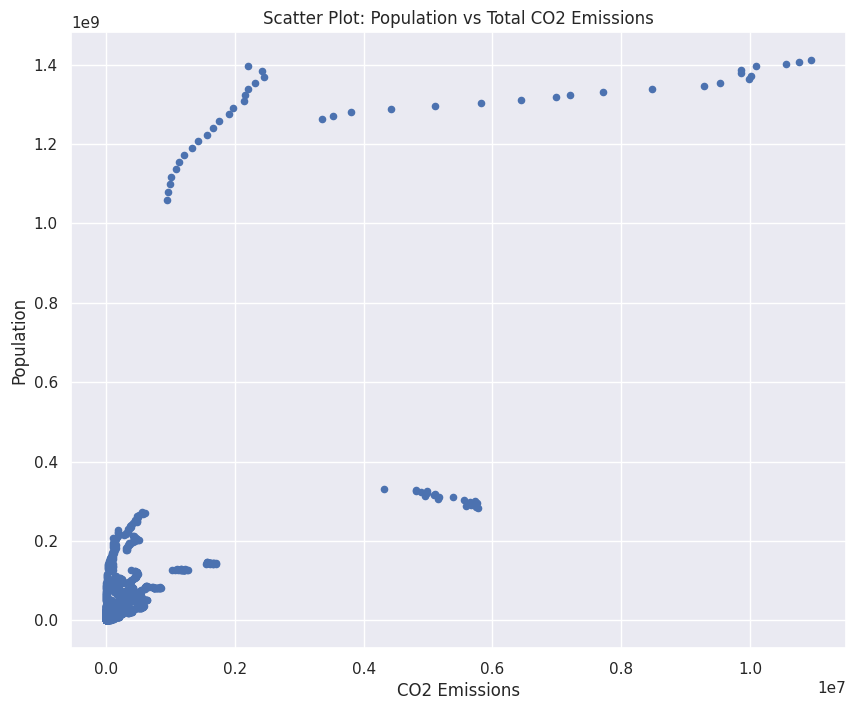

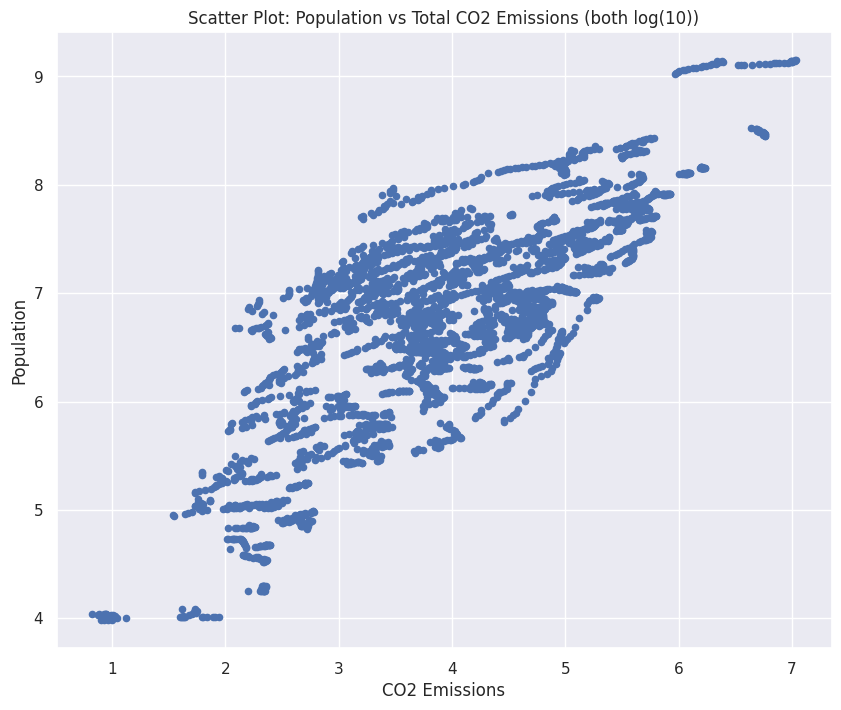

In [723]:
# Plot as a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(co2_vs_pop_df['co2'], co2_vs_pop_df['pop'], label=col, s=20)
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions')
plt.show();


# Plot as a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(co2_vs_pop_df['co2log'], co2_vs_pop_df['poplog'], label=col, s=20)
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions (both log(10))')
plt.show();


Training the Linear Regression Model

In [751]:

lin_x = pd.DataFrame(co2_vs_pop_df['co2'])
lin_y = pd.DataFrame(co2_vs_pop_df['pop'])

x_train, x_test, y_train, y_test = train_test_split(lin_x , lin_y, test_size=0.33)

regr=linear_model.LinearRegression()
regr.fit(x_train,y_train)

# The coefficients
print('Coefficients:', regr.coef_)
print('Intercept:', regr.intercept_)

Coefficients: [[147.14399724]]
Intercept: [13300768.54554895]


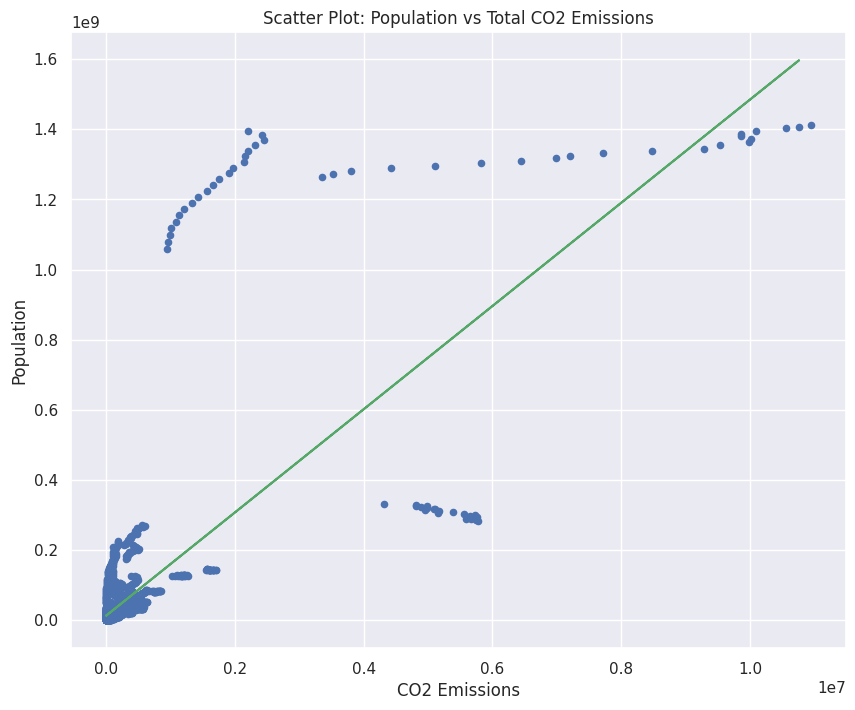

In [752]:
# Plot as a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(co2_vs_pop_df['co2'], co2_vs_pop_df['pop'], label=col, s=20)
plt.plot(x_train,regr.coef_[0][0]*x_train + regr.intercept_[0],'-g', )
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions')
plt.show();

In [753]:
from sklearn.metrics import r2_score
test_y_ = regr.predict(x_test)

# From workshop on Linear Regression
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_-y_test)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_-y_test)**2))
print("R2-score: %.2f" % r2_score(test_y_,y_test))

Mean absolute error: 29347479.04
Residual sum of squares (MSE): 9373756415656326.00
R2-score: 0.42


In [754]:

lin_x = pd.DataFrame(co2_vs_pop_df['co2log'])
lin_y = pd.DataFrame(co2_vs_pop_df['poplog'])

x_train, x_test, y_train, y_test = train_test_split(lin_x , lin_y, test_size=0.33)

regr=linear_model.LinearRegression()
regr.fit(x_train,y_train)

# The coefficients
print('Coefficients:', regr.coef_)
print('Intercept:', regr.intercept_)


Coefficients: [[0.67727336]]
Intercept: [4.02839941]


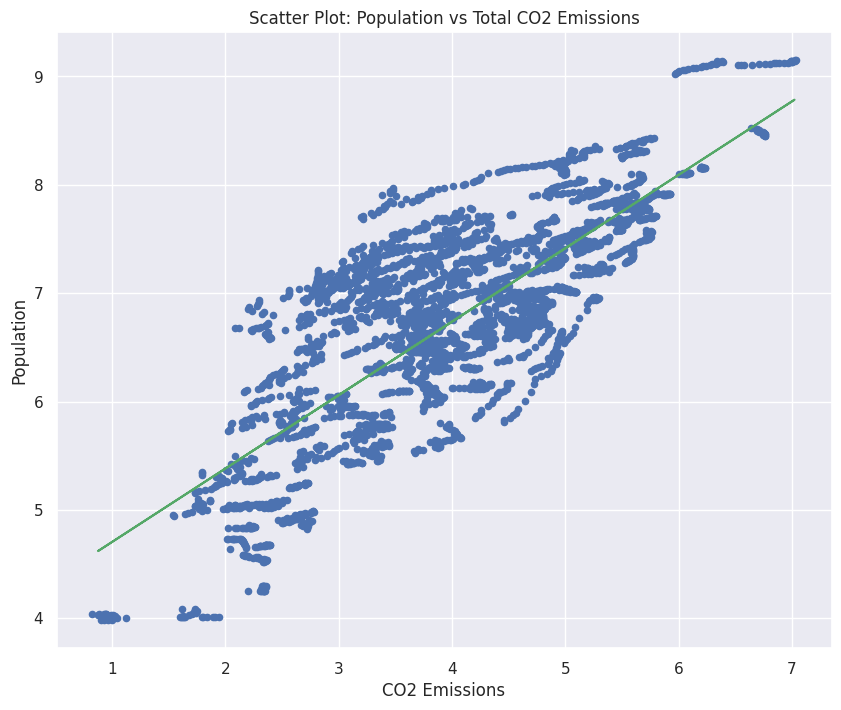

In [755]:
# Plot as a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(co2_vs_pop_df['co2log'], co2_vs_pop_df['poplog'], label=col, s=20)
plt.plot(x_train,regr.coef_[0][0]*x_train + regr.intercept_[0],'-g', )
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions')
plt.show();



Predictions using the model to compute effectiveness.

In [756]:
from sklearn.metrics import r2_score
test_y_ = regr.predict(x_test)

# From workshop on Linear Regression
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_-y_test)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_-y_test)**2))
print("R2-score: %.2f" % r2_score(test_y_,y_test))

Mean absolute error: 0.47
Residual sum of squares (MSE): 0.34
R2-score: 0.41


**(Comment on this)**

### Birthrate vs Emissions

Does a fast growing population also mean more CO2?

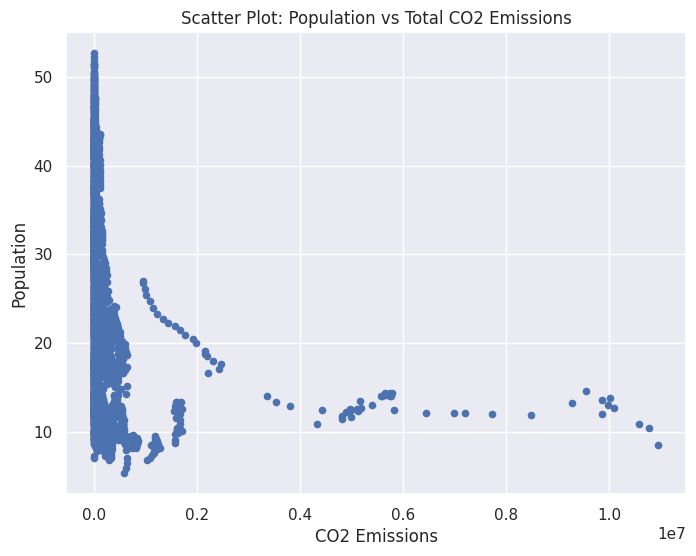

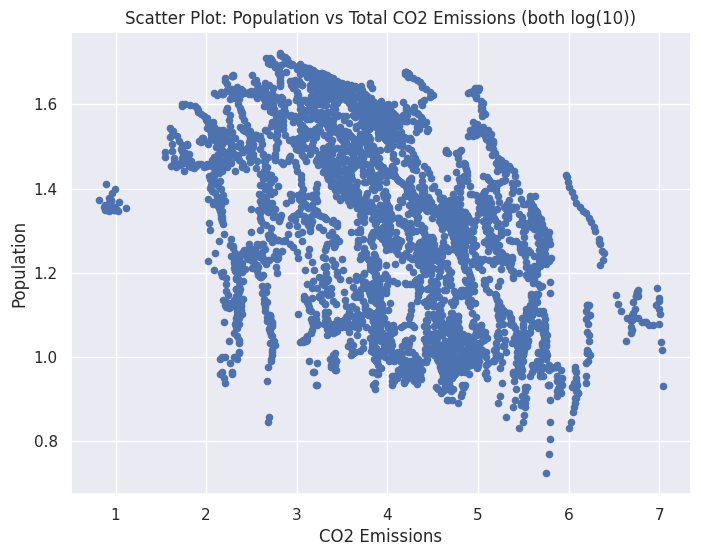

In [759]:
# Plot as a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(co2_vs_pop_df['co2'], co2_vs_pop_df['br'], label=col, s=20)
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions')
plt.show();


# Plot as a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(co2_vs_pop_df['co2log'], co2_vs_pop_df['brlog'], label=col, s=20)
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions (both log(10))')
plt.show();



In [761]:
lin_x = pd.DataFrame(co2_vs_pop_df['co2'])
lin_y = pd.DataFrame(co2_vs_pop_df['br'])

x_train, x_test, y_train, y_test = train_test_split(lin_x , lin_y, test_size=0.33)

regr=linear_model.LinearRegression()
regr.fit(x_train,y_train)

# The coefficients
print('Coefficients:', regr.coef_)
print('Intercept:', regr.intercept_)

Coefficients: [[-2.41536825e-06]]
Intercept: [22.78171562]


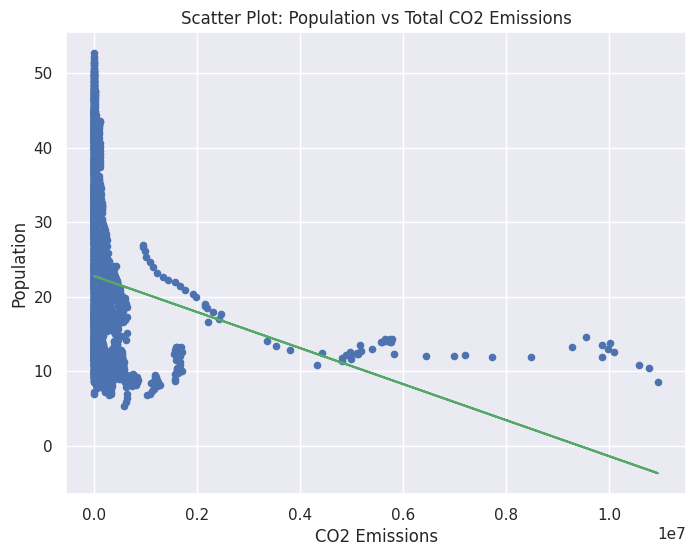

In [762]:
# Plot as a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(co2_vs_pop_df['co2'], co2_vs_pop_df['br'], label=col, s=20)
plt.plot(x_train,regr.coef_[0][0]*x_train + regr.intercept_[0],'-g', )
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions')
plt.show();

In [763]:
test_y_ = regr.predict(x_test)

# From workshop on Linear Regression
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_-y_test)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_-y_test)**2))
print("R2-score: %.2f" % r2_score(test_y_,y_test))

Mean absolute error: 9.15
Residual sum of squares (MSE): 118.54
R2-score: -39.47


In [764]:
lin_x = pd.DataFrame(co2_vs_pop_df['co2log'])
lin_y = pd.DataFrame(co2_vs_pop_df['brlog'])

x_train, x_test, y_train, y_test = train_test_split(lin_x , lin_y, test_size=0.33)

regr=linear_model.LinearRegression()
regr.fit(x_train,y_train)

# The coefficients
print('Coefficients:', regr.coef_)
print('Intercept:', regr.intercept_)


Coefficients: [[-0.09163345]]
Intercept: [1.66557767]


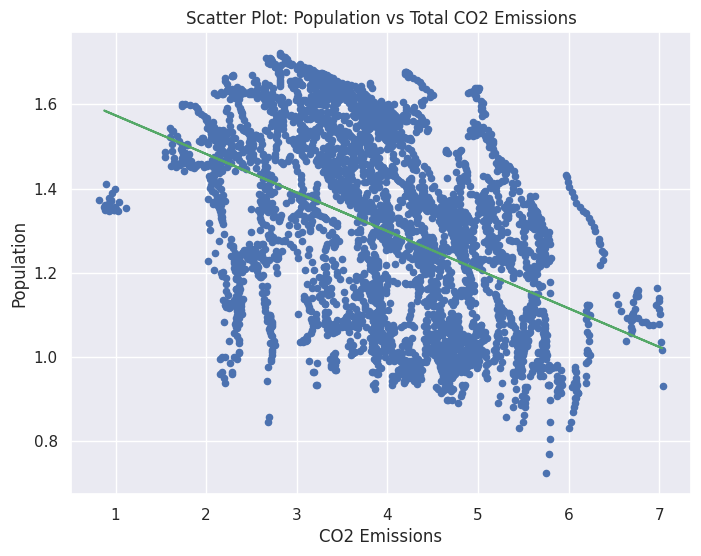

In [765]:
# Plot as a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(co2_vs_pop_df['co2log'], co2_vs_pop_df['brlog'], label=col, s=20)
plt.plot(x_train,regr.coef_[0][0]*x_train + regr.intercept_[0],'-g', )
plt.ylabel('Population')
plt.xlabel('CO2 Emissions')
plt.title('Scatter Plot: Population vs Total CO2 Emissions')
plt.show();

In [766]:
test_y_ = regr.predict(x_test)

# From workshop on Linear Regression
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_-y_test)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_-y_test)**2))
print("R2-score: %.2f" % r2_score(test_y_,y_test))

Mean absolute error: 0.17
Residual sum of squares (MSE): 0.04
R2-score: -2.70


### Conclusion


---
## Q5: Describe the trends in land use by region.

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
AG.LND.TOTL.K2 | Total Land Area | Sq. Km.
AG.LND.TOTL.RU.K2 | Total Rural Land Area | Sq. Km.
AG.LND.TOTL.UR.K2 | Total Urban Land Area | Sq. Km.
AG.LND.AGRI.K2 | Agricultural Land | Sq. Km.
AG.LND.FRST.K2 | Forested Land | Sq. Km.


### Conclusion


---
## Q5: Does Land Usage Type Corollate to Total CO2 Emissions?

In this question, I will use data on land usage area, and plot against CO~2~ emissions.

I will plot each type of land usage data against the emissions for each country. I would intuitively expect to see that a predominance of one type of land usage in an area would have a different effect on overall CO~2~ output, however whether this has an effect from the data remains to be discovered. From this policy decisions can be informed regarding future planning decisions withe a view to Net Zero.

I have selected the following series to answer this question:

StudyCodes: AG.LND, EN.ATM

|Series Code|Description|Unit|
|-|-|-|
AG.LND.TOTL.K2 | Total Land Area | Sq. Km.
AG.LND.TOTL.RU.K2 | Total Rural Land Area | Sq. Km.
AG.LND.TOTL.UR.K2 | Total Urban Land Area | Sq. Km.
AG.LND.AGRI.K2 | Agricultural Land | Sq. Km.
AG.LND.FRST.K2 | Forested Land | Sq. Km.
EN.ATM.CO2E.KT | CO~2~ Emissions | Tons x 10^3 (KT)


In [ ]:
# Extract C02 data for all countries (Reload Fresh)
co2data_df = country_data_df.loc[country_data_df['SeriesCode'] == 'EN.ATM.CO2E.KT']

# Remove 2021 - it's empty for all countries
co2data_df.drop('2021', axis=1, inplace=True)
co2_data_num_fields = numerical_fields.copy()
co2_data_num_fields.remove("2021")

In [906]:
# Extract Land Usage Data for all countries
lnd_tot_df = country_data_df.loc[country_data_df['SeriesCode'] == 'AG.LND.TOTL.K2']
lnd_tot_df.drop('2021', axis=1, inplace=True)

lnd_tot_ru_df = country_data_df.loc[country_data_df['SeriesCode'] == 'AG.LND.TOTL.RU.K2']
lnd_tot_ru_df.drop('2021', axis=1, inplace=True)

lnd_tot_ub_df = country_data_df.loc[country_data_df['SeriesCode'] == 'AG.LND.TOTL.UR.K2']
lnd_tot_ub_df.drop('2021', axis=1, inplace=True)

lnd_ag_df = country_data_df.loc[country_data_df['SeriesCode'] == 'AG.LND.AGRI.K2']
lnd_ag_df.drop('2021', axis=1, inplace=True)

lnd_ff_df = country_data_df.loc[country_data_df['SeriesCode'] == 'AG.LND.FRST.K2']
lnd_ff_df.drop('2021', axis=1, inplace=True)


In [908]:
lnd_vs_co2_df = pd.DataFrame(columns = ['co2','tot','ru','ub','ag','ff'])

# Extract values into a long series
_loop_series = co2data_df[co2_data_num_fields]
_co2_series = pd.concat([_loop_series[col] for col in _loop_series])

_loop_series = lnd_tot_df[co2_data_num_fields]
_lnd_tot_series  = pd.concat([_loop_series[col] for col in _loop_series])

_loop_series = lnd_tot_ru_df[co2_data_num_fields]
_lnd_tot_ru_series  = pd.concat([_loop_series[col] for col in _loop_series])

_loop_series = lnd_tot_ub_df[co2_data_num_fields]
_lnd_tot_ub_series  = pd.concat([_loop_series[col] for col in _loop_series])

_loop_series = lnd_ag_df [co2_data_num_fields]
_lnd_ag_series = pd.concat([_loop_series[col] for col in _loop_series])

_loop_series = lnd_ff_df[co2_data_num_fields]
_lnd_ff_series  = pd.concat([_loop_series[col] for col in _loop_series])



In [909]:
lnd_vs_co2_df['co2'] = list (_co2_series )
lnd_vs_co2_df['tot'] = list (_lnd_tot_series )
lnd_vs_co2_df['ru']  = list (_lnd_tot_ru_series )
lnd_vs_co2_df['ub']  = list (_lnd_tot_ub_series )
lnd_vs_co2_df['ag']  = list (_lnd_ag_series )
lnd_vs_co2_df['ff']  = list (_lnd_ff_series )

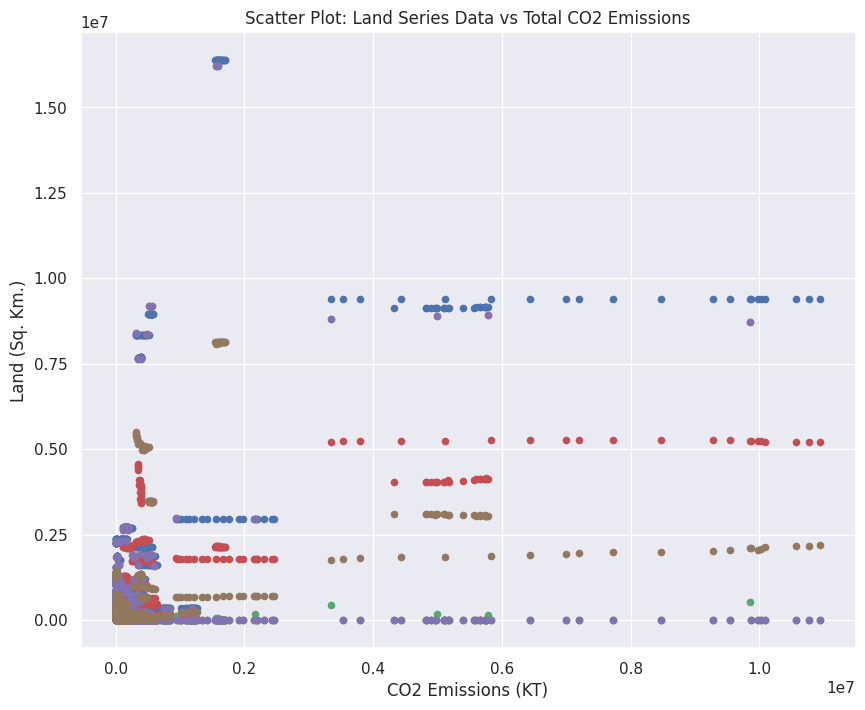

In [915]:
# Plot as a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(lnd_vs_co2_df['co2'], lnd_vs_co2_df['tot'], label=col, s=20)
plt.scatter(lnd_vs_co2_df['co2'], lnd_vs_co2_df['ru'], label=col, s=20)
plt.scatter(lnd_vs_co2_df['co2'], lnd_vs_co2_df['ub'], label=col, s=20)
plt.scatter(lnd_vs_co2_df['co2'], lnd_vs_co2_df['ag'], label=col, s=20)
plt.scatter(lnd_vs_co2_df['co2'], lnd_vs_co2_df['ru'], label=col, s=20)
plt.scatter(lnd_vs_co2_df['co2'], lnd_vs_co2_df['ff'], label=col, s=20)
plt.ylabel('Land (Sq. Km.)')
plt.xlabel('CO2 Emissions (KT)')
plt.title('Scatter Plot: Land Series Data vs Total CO2 Emissions')
plt.show();


### Conclusion


---
## Q7: Show elecricial consumption over time vs renewable production, by region.

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
EN.ATM.CO2E.KT | CO2 Emissions | Tons x 10^3 (KT)
EG.ELC.COAL.ZS       | Electricity production from coal sources (% of total)                                           |
EG.ELC.FOSL.ZS       | Electricity production from oil, gas and coal sources (% of total)                              |
EG.ELC.HYRO.ZS       | Electricity production from hydroelectric sources (% of total)   

EG.ELC.NGAS.ZS       | Electricity production from natural gas sources (% of tal)                                    |
EG.ELC.NUCL.ZS       | Electricity production from nuclear sources (% of total)                                        |
EG.ELC.PETR.ZS       | Electricity production from oil sources (% of total)   
EG.ELC.RNWX.ZS       | Electricity production from renewable sources, excluding hydroelectric (% of total)

### Conclusion


---
## Q8: Is there a correlation between electricity priduced by renewables and CO2 emissions?

I have selected the following series to answer this question:

StudyCodes: EN.ATM

|Series Code|Description|Unit|
|-|-|-|
EN.ATM.CO2E.KT | CO2 Emissions | Tons x 10^3 (KT)

### Conclusion


In [259]:
# Plot graph of birth and death rates on a world map



df_SP_DYN_CDRT_IN = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.DYN.CDRT.IN']
df_SP_DYN_CBRT_IN = country_data_df.loc[country_data_df['SeriesCode'] == 'SP.DYN.CBRT.IN']

_range = [str(x).zfill(2) for x in range(2000,2021+1)]
_years = pd.Index(_range)



fig = go.Figure(go.Scatter(x=df_SP_DYN_CBRT_IN['2021'], y=df_SP_DYN_CDRT_IN['2021'], text=df_SP_DYN_CDRT_IN.Country, mode='markers'))
#fig.update_xaxes(title_text='GDP per Capita', type='log')
#fig.update_yaxes(title_text='Life Expectancy')
py.iplot(fig, filename='pandas-multiple-scatter')